In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [164]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [165]:
df_raw = pd.read_csv("E:\\IBM\\Classification\\heart.csv")

In [166]:
df_raw

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [211]:
df = df_raw.drop_duplicates()
print("Total rows after removing duplicates:", len(df))

Total rows after removing duplicates: 302


In [212]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [247]:
df.head(30)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [213]:
# getting some info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [214]:
# number of rows and columns in the dataset
df.shape

(302, 14)

In [215]:
# checking for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [216]:
# statistical measures about the data
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [217]:
# checking the distribution of Target Variable
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [218]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [219]:
print(X)

[[52.  1.  0. ...  2.  2.  3.]
 [53.  1.  0. ...  0.  0.  3.]
 [70.  1.  0. ...  0.  0.  3.]
 ...
 [52.  1.  0. ...  2.  1.  3.]
 [59.  1.  3. ...  2.  0.  2.]
 [54.  1.  0. ...  1.  1.  3.]]


In [220]:
print(y)

[0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1
 0 1 1 0 1 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0 1 0
 0 1 0 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 1 1 1
 0 1 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 0 1 0 1
 1 0 0 1 1 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 1
 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1
 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 1
 0 1 1 0 0 0]


In [224]:
#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [225]:
print(X_train.shape, X_test.shape)

(241, 13) (61, 13)


In [227]:
print(y_train.shape, y_test.shape)

(241,) (61,)


In [180]:
# Scaling
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test  = scaler.transform(X_test)

In [228]:
#Decision_Tree_classification
from sklearn.preprocessing import StandardScaler
dt_sc = StandardScaler()
X_train = dt_sc.fit_transform(X_train)
X_test = dt_sc.transform(X_test)

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.7868852459016393


In [231]:
# KNN_Classification
from sklearn.preprocessing import StandardScaler
knn_sc = StandardScaler()
X_train = knn_sc.fit_transform(X_train)
X_test = knn_sc.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 2, metric = 'minkowski', p = 2)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.7377049180327869


In [232]:
# Logistic_Regression_Classification
from sklearn.preprocessing import StandardScaler
log_sc = StandardScaler()
X_train = log_sc.fit_transform(X_train)
X_test = log_sc.transform(X_test)

from sklearn.linear_model import LogisticRegression
log = LogisticRegression(random_state = 0)
log.fit(X_train, y_train)

y_pred_log = log.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", acc_log)

Logistic Regression Accuracy: 0.8360655737704918


In [233]:
# Naive_Bayes_Classification
from sklearn.preprocessing import StandardScaler
nb_sc = StandardScaler()
X_train = nb_sc.fit_transform(X_train)
X_test = nb_sc.transform(X_test)

from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.8032786885245902


In [234]:
#Random_Forest_Classification
from sklearn.preprocessing import StandardScaler
rf_sc = StandardScaler()
X_train = rf_sc.fit_transform(X_train)
X_test = rf_sc.transform(X_test)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.7704918032786885


In [235]:
#Support_Vector_Classification
from sklearn.preprocessing import StandardScaler
svc_sc = StandardScaler()
X_train = svc_sc.fit_transform(X_train)
X_test = svc_sc.transform(X_test)

from sklearn.svm import SVC
svc = SVC(kernel = 'linear', random_state = 0)
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)

print("Support Vector Classifier Accuracy:", acc_svc)

Support Vector Classifier Accuracy: 0.819672131147541


In [236]:
# Best Model Comparison Table
results = {
    "Model": ["Decision Tree", "KNN", "Logistic Regression", "Naive Bayes", "Random Forest", "SVC"],
    "Accuracy": [acc_dt, acc_knn, acc_log, acc_nb, acc_rf, acc_svc]}
results_df = pd.DataFrame(results)
print("\nModel Accuracy Comparison:\n")
print(results_df)


Model Accuracy Comparison:

                 Model  Accuracy
0        Decision Tree  0.786885
1                  KNN  0.737705
2  Logistic Regression  0.836066
3          Naive Bayes  0.803279
4        Random Forest  0.770492
5                  SVC  0.819672


In [237]:
# Confusion_Matrix
from sklearn.metrics import confusion_matrix

#Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nDecision Tree Confusion Matrix:\n", cm_dt)

#KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nKNN Confusion Matrix:\n", cm_knn)

#Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
print("\nLogistic Regression Confusion Matrix:\n", cm_log)

#Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("\nNaive Bayes Confusion Matrix:\n", cm_nb)

#Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nRandom Forest Confusion Matrix:\n", cm_rf)

#Support Vector Classifier
cm_svc = confusion_matrix(y_test, y_pred_svc)
print("\nSupport Vector Classifier Confusion Matrix:\n", cm_svc)


Decision Tree Confusion Matrix:
 [[18  7]
 [ 6 30]]

KNN Confusion Matrix:
 [[22  3]
 [13 23]]

Logistic Regression Confusion Matrix:
 [[20  5]
 [ 5 31]]

Naive Bayes Confusion Matrix:
 [[20  5]
 [ 7 29]]

Random Forest Confusion Matrix:
 [[20  5]
 [ 9 27]]

Support Vector Classifier Confusion Matrix:
 [[19  6]
 [ 5 31]]


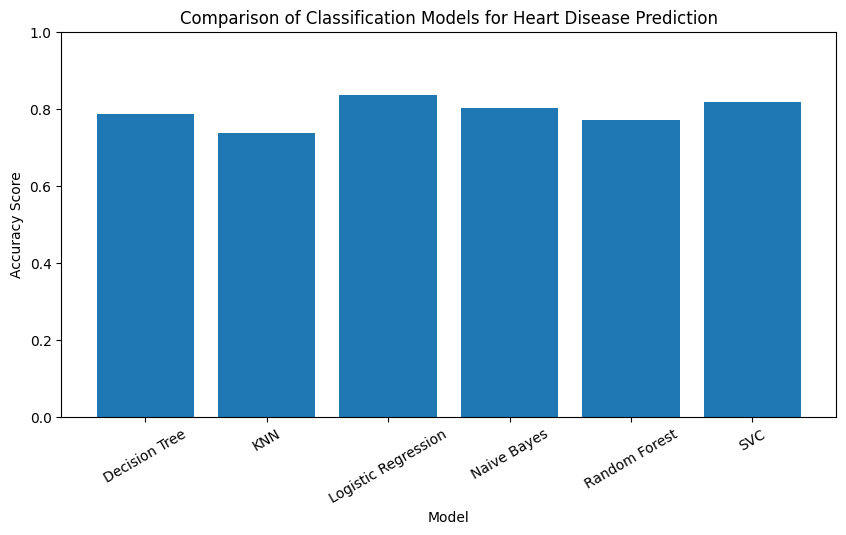

In [238]:
plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Comparison of Classification Models for Heart Disease Prediction")
plt.xlabel("Model")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

In [255]:
# Using Logistic Classification as final model
import numpy as np
import pandas as pd

df_final = pd.read_csv("E:\\IBM\\Classification\\heart.csv")

from sklearn.preprocessing import StandardScaler
final_sc = StandardScaler()
X_train = final_sc.fit_transform(X_train)
X_test = final_sc.transform(X_test)

from sklearn.linear_model import LogisticRegression
final_dt = LogisticRegression(random_state = 0)
final_dt.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [256]:
def predict_heart_risk(input_list):
    cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']
    df_input = pd.DataFrame([input_list], columns=cols)
    arr = np.array(input_list).reshape(1, -1)
    pred = final_dt.predict(arr)

    if (pred[0] == 1):
        return ('High chance of Heart Disease')
    else:
        return ('Low chance of Heart Disease')

In [257]:
test_sample = [51, 0, 2, 140, 308, 0, 0, 142, 0, 1.5, 2, 1, 2]
print(predict_heart_risk(test_sample))

Low chance of Heart Disease


In [258]:
test_sample_1 = [59, 1, 1, 140, 221, 0, 1, 164, 1, 0.0, 2, 0, 2]
print(predict_heart_risk(test_sample_1))

High chance of Heart Disease


In [259]:
test_sample_2 = [53, 1, 0, 140, 203, 1, 0, 155, 1, 3.1, 0, 0, 3]
print(predict_heart_risk(test_sample_2))

Low chance of Heart Disease


In [260]:
test_sample_3 = [45, 1, 0, 104, 208, 0, 0, 148, 1, 3.0, 1, 0, 2]
print(predict_heart_risk(test_sample_3))

High chance of Heart Disease


In [261]:
test_sample_4 = [42, 0, 2, 120, 209, 0, 1, 173, 0, 0.0, 1, 0, 2]
print(predict_heart_risk(test_sample_4))

High chance of Heart Disease
